In [1]:
%config InlineBackend.figure_formats = ['svg']

In [2]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['FreeSans']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dfs = {
    'mimic_dBCQf_shifted': [],
}
version_list = list(range(40))

for ver in version_list:
    try:
        import re
        text = open(f'../4_BCQf/logs_shifted/mimic_dBCQf_shifted/version_{ver}/hparams.yaml').read()
        meta = {
            'threshold': float(re.search(r'threshold: ([\d.]+)', text).group(1)),
            'seed': int(re.search(r'seed: (\d+)', text).group(1)),
        }
        df = pd.read_csv(f'../4_BCQf/logs_shifted/mimic_dBCQf_shifted/version_{ver}/metrics.csv')
        df['version'] = ver
        df['threshold'] = meta['threshold']
        df['seed'] = meta['seed']
        dfs['mimic_dBCQf_shifted'].append(df)
    except:
        pass

In [5]:
tau_list = [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.75, 0.9999]

In [6]:
colors = {
    '0.0': 'tab:red',
    '0.01': 'tab:orange',
    '0.05': 'tab:olive',
    '0.1': 'tab:green',
    '0.3': 'tab:cyan',
    '0.5': 'tab:blue',
    '0.75': 'tab:purple',
    '0.9999': 'tab:pink',
}

In [7]:
from operator import itemgetter, attrgetter
import numpy as np

# Reference: https://github.com/Ragheb2464/preto-front/blob/master/2d.py
def pareto2d(data):
    sorted_data = sorted(data, key=itemgetter(0, 1), reverse=True)
    pareto_idx = list()
    pareto_idx.append(0)
    cutoff = sorted_data[0][1]
    for i in range(1, len(sorted_data)):
        if sorted_data[i][1] > cutoff:
            pareto_idx.append(i)
            cutoff = sorted_data[i][1]
    return pareto_idx

## Pareto Frontier Validation Trade-offs

findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sa

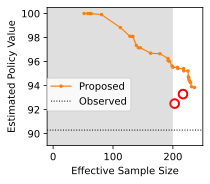

In [8]:
fig = plt.figure(figsize=(2.8,2.5))

dfs_2 = pd.concat(dfs['mimic_dBCQf_shifted']).sort_values(by=['val_wis', 'val_ess'], ascending=False)
pareto_idx = pareto2d(dfs_2[['val_wis', 'val_ess']].values)
plt.plot(dfs_2.iloc[pareto_idx]['val_ess'], dfs_2.iloc[pareto_idx]['val_wis'], ls='-', lw=1.2, marker='.', ms=5, c='tab:orange', label='Proposed', clip_on=False)

plt.scatter([202.913132, 216.866272], [92.497391, 93.288460], edgecolor='r', facecolor='none', s=75, lw=2)

plt.xlabel('Effective Sample Size')
plt.ylabel('Estimated Policy Value')
plt.xlim(-10,250)
plt.ylim(89,100.5)
plt.axhline(90.2936, ls=':', lw=1, c='k', label='Observed')
plt.fill_between([-20,200], [80,80], [120,120], facecolor='gray', alpha=0.25)
# plt.axvline(200, ls=':', lw=1, c='gray')
plt.legend(loc='best', bbox_to_anchor=(0.17, 0.125, 0.4, 0.4))
plt.savefig('./fig/mimic_validation_pareto_frontier_new.pdf', bbox_inches='tight')
plt.show()

## Test performance

In [9]:
state_dim = 64
num_actions = 25
horizon = 20

In [10]:
import sys
sys.path.insert(0, '../4_BCQf')
from model import BCQf
from model import all_subactions_vec
from data import EpisodicBuffer as EpisodicBufferFF
from data import remap_rewards

In [11]:
from evaluate import (
    EpisodicBufferO, offline_evaluation_O,
    EpisodicBufferF, offline_evaluation_F,
)

In [12]:
from torch.utils.data import DataLoader
from types import SimpleNamespace
from tqdm import tqdm

In [13]:
dfs_2 = pd.concat(dfs['mimic_dBCQf_shifted']).sort_values(by=['val_wis', 'val_ess'], ascending=False)
pareto_idx = pareto2d(dfs_2[['val_wis', 'val_ess']].values)
dfs_2_pareto = dfs_2.iloc[pareto_idx]

In [14]:
len(dfs_2_pareto)

32

In [15]:
test_episodes_O = EpisodicBufferF(state_dim, num_actions, horizon)
test_episodes_O.load('../data/episodes+encoded_state+knn_pibs_factored/shifted_test_data.pt')
test_episodes_O.reward = remap_rewards(test_episodes_O.reward, SimpleNamespace(**{'R_immed': 0.0, 'R_death': 0.0, 'R_disch': 100.0}))

tmp_test_episodes_loader_O = DataLoader(test_episodes_O, batch_size=len(test_episodes_O), shuffle=False)
test_batch_O = next(iter(tmp_test_episodes_loader_O))

Episodic Buffer loaded with 2757 episides.


In [20]:
results_2 = []
for _, row in tqdm(dfs_2_pareto.iterrows(), total=dfs_2_pareto.shape[0]):
    ver = int(row['version'])
    bcq_model = BCQf.load_from_checkpoint(
        checkpoint_path=f'../4_BCQf/logs_shifted/mimic_dBCQf_shifted/version_{ver}/step=10000.ckpt',
        map_location='cpu',
        weights_only=False
    )
    bcq_model.eval()
    bcq_model.all_subactions_vec = all_subactions_vec
    test_wis, test_ess = offline_evaluation_F(bcq_model, test_batch_O, weighted=True, eps=0.01)
    results_2.append((test_wis, test_ess))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:29<00:00,  1.09it/s]


In [21]:
results_1 = np.array(results_1)
results_2 = np.array(results_2)

findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sa

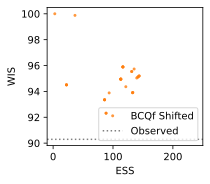

In [23]:
fig = plt.figure(figsize=(2.8, 2.5))
plt.plot(
    np.array(results_2)[:, 1], np.array(results_2)[:, 0],
    ls='', marker='.', c='tab:orange', alpha=0.8, ms=6, mew=0,
    label='BCQf Shifted', zorder=11
)
plt.xlabel('ESS')
plt.ylabel('WIS')
plt.xlim(-10, 250)
plt.axhline(90.2936, ls=':', c='grey', label='Observed')
plt.legend(loc='lower right')
plt.show()

## Model selection

In [24]:
# Sweep through all possible ESS thresholds
sweep_ESS_cutoffs = np.arange(250)
sweep_ESS_results = []
for ESS_cutoff in sweep_ESS_cutoffs:
# BCQ baseline not available: df_1_candidates = dfs_1_pareto.reset_index()
# BCQ baseline not available: df_1_candidates = df_1_candidates[df_1_candidates['val_ess'] >= ESS_cutoff].sort_values(by=['val_wis', 'val_ess'], ascending=False)
    df_2_candidates = dfs_2_pareto.reset_index()
    df_2_candidates = df_2_candidates[df_2_candidates['val_ess'] >= ESS_cutoff].sort_values(by=['val_wis', 'val_ess'], ascending=False)
    
    try:
# BCQ baseline not available: idx1 = df_1_candidates.index[0]
        res1 = results_1[idx1]
    except:
        res1 = [np.nan, np.nan]
    
    try:
        idx2 = df_2_candidates.index[0]
        res2 = results_2[idx2]
    except:
        res2 = [np.nan, np.nan]
    
    sweep_ESS_results.append(np.hstack([res1, res2]))

In [25]:
df_sweep_ESS_results = pd.DataFrame(sweep_ESS_results, columns=['Baseline WIS', 'Baseline ESS', 'Proposed WIS', 'Proposed ESS'])

findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: FreeSans
findfont: Generic family 'sa

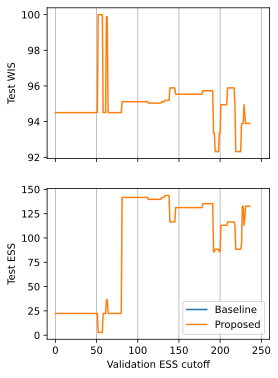

In [26]:
fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)
plt.sca(axes[0])
plt.plot(df_sweep_ESS_results['Baseline WIS'], c='tab:blue', label='Baseline')
plt.plot(df_sweep_ESS_results['Proposed WIS'], c='tab:orange', label='Proposed')
plt.ylabel('Test WIS')
plt.grid(axis='x')

plt.sca(axes[1])
plt.plot(df_sweep_ESS_results['Baseline ESS'], c='tab:blue', label='Baseline')
plt.plot(df_sweep_ESS_results['Proposed ESS'], c='tab:orange', label='Proposed')
plt.ylabel('Test ESS')
plt.grid(axis='x')

plt.xlim(-10, 260)
plt.xlabel('Validation ESS cutoff')
plt.legend()

plt.savefig('./fig/mimic_model_selection.pdf', bbox_inches='tight')
plt.show()

In [27]:
ESS_cutoff = 200

In [28]:
# BCQ baseline not available: df_1_candidates = dfs_1_pareto.reset_index()
# BCQ baseline not available: df_1_candidates = df_1_candidates[df_1_candidates['val_ess'] >= ESS_cutoff].sort_values(by=['val_wis', 'val_ess'], ascending=False)
df_2_candidates = dfs_2_pareto.reset_index()
df_2_candidates = df_2_candidates[df_2_candidates['val_ess'] >= ESS_cutoff].sort_values(by=['val_wis', 'val_ess'], ascending=False)

In [29]:
# BCQ baseline not available: df_1_candidates

In [30]:
df_2_candidates

,index,epoch,iteration,step,val_ess,val_qvalues,val_wis,version,threshold,seed
18,34,2,3634.0,3633,200.130325,3.695056,95.522263,27,0.5000,2
19,56,4,5968.0,5967,207.730957,7.628432,95.510086,28,0.5000,3
20,94,6,9902.0,9901,208.210953,15.449560,95.418549,28,0.5000,3
21,52,3,5501.0,5500,217.576447,7.320690,95.413612,22,0.3000,2
22,63,4,6668.0,6667,217.639069,8.766980,95.358459,27,0.5000,2
23,60,4,6368.0,6367,218.309540,8.166596,95.224876,28,0.5000,3
24,94,6,9902.0,9901,225.211319,15.323320,95.212112,26,0.5000,1
25,77,5,8135.0,8134,225.792801,12.075537,94.729141,28,0.5000,3
26,92,6,9702.0,9701,226.500107,15.833827,94.667503,29,0.5000,4
27,92,6,9702.0,9701,226.855164,9.786494,94.471733,36,0.9999,1


In [31]:
# BCQ baseline not available: idx1 = df_1_candidates.index[0]
idx2 = df_2_candidates.index[0]

In [33]:
print('Test performance')
print('Factored BCQ', idx2, results_2[idx2])

Test performance
Factored BCQ 18 [93.35134791 85.92043976]


In [34]:
# BCQ baseline not available: df_1_candidates.loc[[idx1]].to_csv('best_BCQ_meta.csv', index=False)
df_2_candidates.loc[[idx2]].to_csv('best_BCQf_shifted_meta.csv', index=False)